# Guided Numeric Exploration — Movies 2000–2026
_Exploratory walkthrough of ratings, popularity, language, and overview text_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [sumitkumar1802/movies-dataset2000-2026](https://www.kaggle.com/datasets/sumitkumar1802/movies-dataset2000-2026)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.
Indented lines signify code is part of a larger function or loop. Functions are used to keep the exploratory process simple and reusable.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Distribution](#Univariate)** <br>
	- 3.1 Ratings and vote counts
	- 3.2 Release years and languages
**4. [Popularity Inequality](#Pareto)** <br>
**5. [Language, Year, and Rating](#Multivariate)** <br>
**6. [Overview Text Features](#Text)** <br>
**7. [Top and Bottom Films](#Tops)** <br>
**8. [What Associates with High Rating](#Association)** <br>
**9. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This notebook is a guided observational walkthrough of a compact movie table: roughly **2,000 titles** with TMDB-style fields — title, original language, overview text, release date, average rating, and vote count.

My goal is to understand **how ratings and attention distribute** across years and languages, whether overview length tracks rating at all, and how vote-count concentration creates a Matthew-effect style popularity trap. I also check a second file in the same dataset (`Top_rated_movies (1).csv`): it looks large at 10,000 rows, but uniqueness tells a different story.

I start with schema and data-quality checks, then move through univariate shapes, cumulative vote inequality, language/year crosstabs, simple text features, and a careful associational view. Interpretations after each plot are working notes — associations in this scrape, not causal claims about film quality.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves the CSV both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "movie_data.csv"
KAGGLE_SLUG = "sumitkumar1802/movies-dataset2000-2026"

EXPECTED_COLS = [
    "id", "title", "original_language", "overview",
    "release_date", "original_title", "vote_average", "vote_count",
]


def resolve_csv_path(basename: str = CSV_BASENAME) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            assert p.is_file()
            return p
        for p in kaggle_root.rglob("*.csv"):
            if "movie" in p.name.lower():
                assert p.is_file()
                return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    assert p.exists(), f"expected {basename} under {root}; found {[x.name for x in root.iterdir()]}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing_cols = set(EXPECTED_COLS) - set(df.columns)
assert not missing_cols, f"missing columns: {sorted(missing_cols)}"
assert len(df) >= 1500, f"unexpectedly small movie_data: {len(df)}"
assert df["vote_average"].between(0, 10).all(), "vote_average outside 0–10"

# Companion file (data-quality contrast)
top_path = resolve_csv_path("Top_rated_movies (1).csv")
top = pd.read_csv(top_path, low_memory=False)
print("Top-rated CSV:", top_path)
print(
    "Top-rated rows / unique ids: {} / {}".format(
        len(top), top["id"].nunique() if "id" in top.columns else "n/a"
    )
)

# Feature engineering
df["release_dt"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_dt"].dt.year
df["overview"] = df["overview"].fillna("")
df["overview_chars"] = df["overview"].str.len()
df["overview_words"] = df["overview"].str.split().str.len().fillna(0).astype(int)
df["in_focus_window"] = df["year"].between(2000, 2026)

unique_count = []
for x in df.columns:
    unique_count.append([x, df[x].nunique(dropna=False), int(df[x].isnull().sum())])

print("Missing Values: {}".format(df.isnull().sum().sum()))
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Unique movie ids: {}".format(df["id"].nunique()))
print("Years with non-null release: {}–{}".format(int(df["year"].min()), int(df["year"].max())))
print("Share in 2000–2026 window: {:.1%}".format(df["in_focus_window"].mean()))
print("Mean vote_average / median vote_count: {:.2f} / {:.0f}".format(
    df["vote_average"].mean(), df["vote_count"].median()
))


Top-rated CSV: /Users/nicapotato/.cache/kagglehub/datasets/sumitkumar1802/movies-dataset2000-2026/versions/6/Top_rated_movies (1).csv
Top-rated rows / unique ids: 10000 / 20
Missing Values: 12
Dataframe Dimension: 2000 Rows, 13 Columns
Unique movie ids: 1991
Years with non-null release: 1938–2028
Share in 2000–2026 window: 81.5%
Mean vote_average / median vote_count: 6.67 / 3328


**Code Explanation and Reasoning:** <br>
I assert the expected schema and a sane rating range, then immediately surface the companion file's uniqueness problem — if a "top-rated" table has thousands of rows but only tens of unique ids, treating it as a film-level panel would invent phantom movies.

I parse `release_date` into `year`, engineer overview length features (characters and words), and flag a **2000–2026 focus window**. The dataset title suggests that window, but the scrape also contains older (and a few future-dated) titles; I keep them in the table and subset when the analysis needs a clean decade band.


In [3]:
df.sample(3, random_state=7)


,id,title,original_language,overview,release_date,original_title,vote_average,vote_count,release_dt,year,overview_chars,overview_words,in_focus_window
1072,620,Ghostbusters,en,"After losing their university jobs, three para...",1984-06-08,Ghostbusters,7.496,9745,1984-06-08,1984.0,172,25,False
1048,190859,American Sniper,en,U.S. Navy SEAL Chris Kyle takes his sole missi...,2014-12-25,American Sniper,7.412,13639,2014-12-25,2014.0,473,83,True
204,967998,Fatal Conspiracy,pt,"Davi Martins, a commercial director of a finan...",2022-05-26,Conspiração Fatal,7.000,3,2022-05-26,2022.0,438,74,True


In [4]:
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Missing"]).sort_values("Unique", ascending=False))

# Explicit data-quality contrast
print("\n=== Data-quality finding: Top_rated_movies (1).csv ===")
print("rows={:,}  unique_id={:,}  duplication_factor≈{:.0f}x".format(
    len(top), top["id"].nunique(), len(top) / max(top["id"].nunique(), 1)
))
top_dedup = top.drop_duplicates(subset=["id"])
print("After id-dedupe: {} rows".format(len(top_dedup)))
print("Focus analysis stays on movie_data.csv ({} rows, {} unique ids).".format(
    len(df), df["id"].nunique()
))


Dataframe Dimension: 2000 Rows, 13 Columns


,Column,Unique,Missing
0,id,1991,0
3,overview,1976,0
5,original_title,1966,0
1,title,1962,0
4,release_date,1646,4
8,release_dt,1646,4
7,vote_count,1575,0
6,vote_average,1231,0
10,overview_chars,479,0
11,overview_words,118,0



=== Data-quality finding: Top_rated_movies (1).csv ===
rows=10,000  unique_id=20  duplication_factor≈500x
After id-dedupe: 20 rows
Focus analysis stays on movie_data.csv (2000 rows, 1991 unique ids).


**Interpretation** <br>
`movie_data.csv` is the honest working table: ~2,000 rows, nearly unique ids, light missingness mostly in overview/date. The companion `Top_rated_movies (1).csv` has **10,000 rows but only ~20 unique movie ids** — massive duplication. I optionally note the deduped size, then **ignore that file for analysis**. Older release years still appear in `movie_data`; the 2000–2026 band is a focus lens, not the full support of the scrape.


# **3. Univariate Distribution:** <a id="Univariate"></a>
### 3.1 Ratings and vote counts


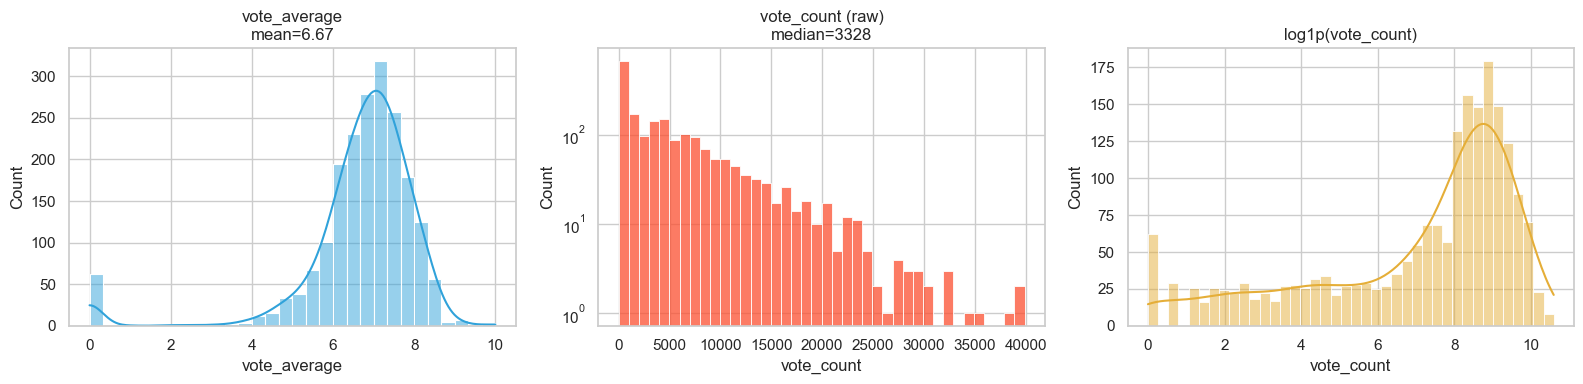

AGENT_SUMMARY vote_average: mean=6.674 std=1.516 p10=5.47 p90=8.00
AGENT_SUMMARY vote_count: mean=5178 median=3328 p90=13639 max=39900


In [5]:
# Outcome / numeric Distributions
f, ax = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

sns.histplot(df["vote_average"], bins=30, kde=True, ax=ax[0], color="#30a2da")
ax[0].set_title("vote_average\nmean={:.2f}".format(df["vote_average"].mean()))

sns.histplot(df["vote_count"], bins=40, kde=False, ax=ax[1], color="#fc4f30")
ax[1].set_title("vote_count (raw)\nmedian={:.0f}".format(df["vote_count"].median()))
ax[1].set_yscale("log")

sns.histplot(np.log1p(df["vote_count"]), bins=40, kde=True, ax=ax[2], color="#e5ae38")
ax[2].set_title("log1p(vote_count)")

plt.tight_layout()
plt.show()

print("AGENT_SUMMARY vote_average: mean={:.3f} std={:.3f} p10={:.2f} p90={:.2f}".format(
    df["vote_average"].mean(), df["vote_average"].std(),
    df["vote_average"].quantile(0.1), df["vote_average"].quantile(0.9),
))
print("AGENT_SUMMARY vote_count: mean={:.0f} median={:.0f} p90={:.0f} max={:.0f}".format(
    df["vote_count"].mean(), df["vote_count"].median(),
    df["vote_count"].quantile(0.9), df["vote_count"].max(),
))


**Code Explanation:** <br>
Three views of the two core numerics: rating average, raw vote count (log y-scale because of a heavy right tail), and log1p votes for shape. Empiric moments ride in the subplot titles so the plot and the printed summary agree.


### 3.2 Release years and languages


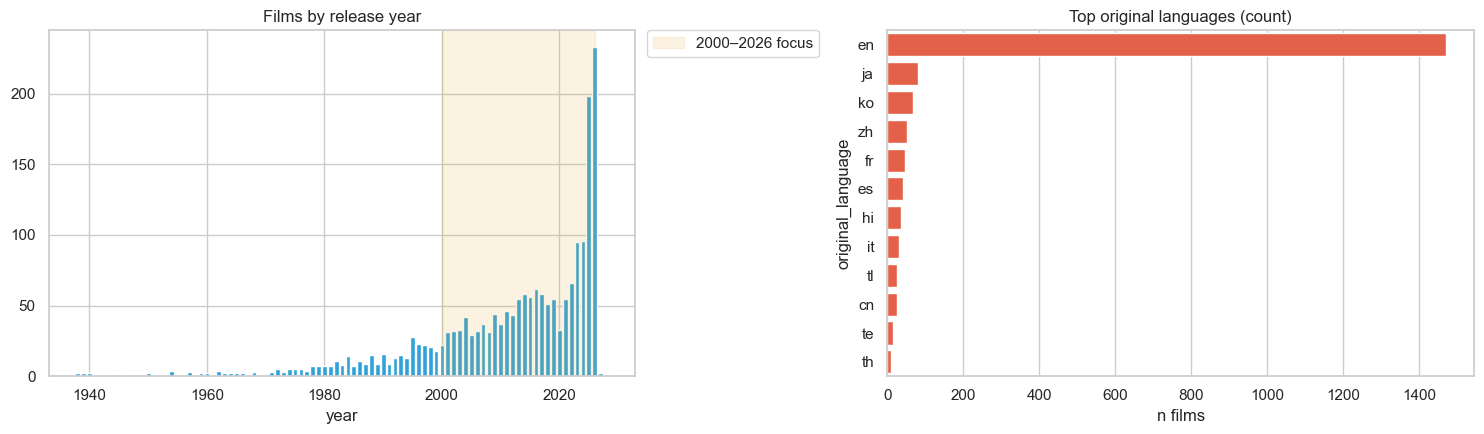

AGENT_SUMMARY year: n_null=4 share_pre_2000=18.1% share_2000_2026=81.5% share_after_2026=0.1%
AGENT_SUMMARY languages: n_unique=37 top3=[('en', 1470), ('ja', 80), ('ko', 69)]


In [6]:
# Year and language frequency
f, ax = plt.subplots(1, 2, figsize=(15, 4.5))

year_counts = df["year"].dropna().astype(int).value_counts().sort_index()
ax[0].bar(year_counts.index, year_counts.values, color="#30a2da", width=0.8)
ax[0].axvspan(2000, 2026, color="#e5ae38", alpha=0.15, label="2000–2026 focus")
ax[0].set_title("Films by release year")
ax[0].set_xlabel("year")
ax[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

lang = df["original_language"].value_counts().head(12)
sns.barplot(x=lang.values, y=lang.index, ax=ax[1], color="#fc4f30")
ax[1].set_title("Top original languages (count)")
ax[1].set_xlabel("n films")

plt.tight_layout()
plt.show()

print("AGENT_SUMMARY year: n_null={:.0f} share_pre_2000={:.1%} share_2000_2026={:.1%} share_after_2026={:.1%}".format(
    df["year"].isna().sum(),
    (df["year"] < 2000).mean(),
    df["in_focus_window"].mean(),
    (df["year"] > 2026).mean(),
))
print("AGENT_SUMMARY languages: n_unique={} top3={}".format(
    df["original_language"].nunique(),
    list(df["original_language"].value_counts().head(3).items()),
))


**Interpretation:** <br>
The year histogram is not a clean 2000–2026 rectangle: an older tail (classics and backfill) and a dense modern peak sit alongside the branded window. English dominates language counts, but non-English titles are numerous enough for language × rating comparisons later. Vote counts are the more skewed object — that skew is the popularity story.


# **4. Popularity Inequality:** <a id="Pareto"></a>


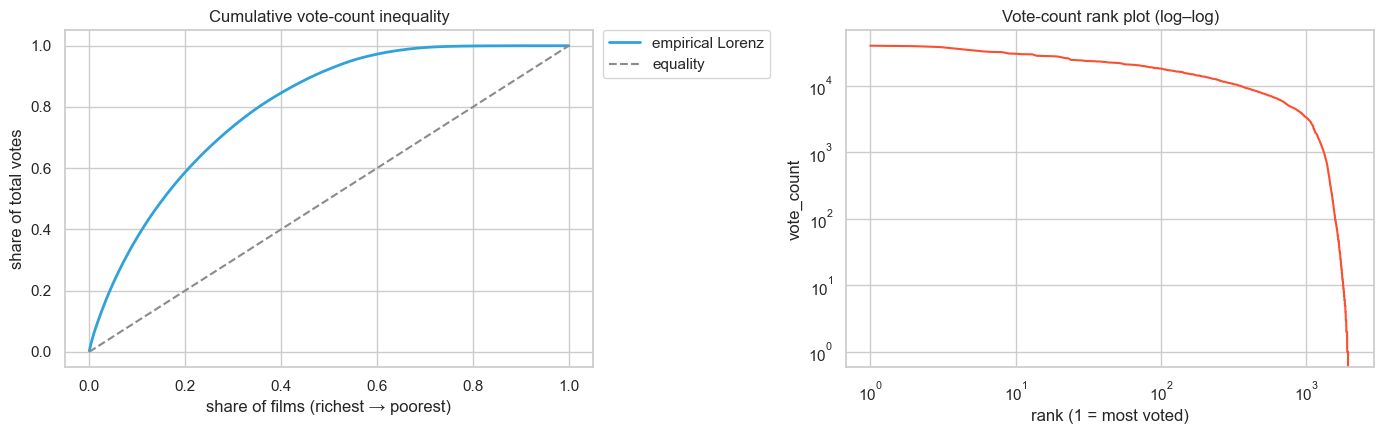

AGENT_SUMMARY pareto: top_1pct_vote_share=6.1% top_10pct_vote_share=37.3% gini≈-0.596


In [7]:
# Pareto / cumulative vote_count inequality (Matthew effect)
votes = df.sort_values("vote_count", ascending=False).reset_index(drop=True)
votes["cum_votes"] = votes["vote_count"].cumsum()
votes["cum_share"] = votes["cum_votes"] / votes["vote_count"].sum()
votes["film_share"] = (np.arange(len(votes)) + 1) / len(votes)

top1 = votes.loc[: max(int(0.01 * len(votes)) - 1, 0), "vote_count"].sum() / votes["vote_count"].sum()
top10 = votes.loc[: max(int(0.10 * len(votes)) - 1, 0), "vote_count"].sum() / votes["vote_count"].sum()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(votes["film_share"], votes["cum_share"], color="#30a2da", lw=2, label="empirical Lorenz")
ax[0].plot([0, 1], [0, 1], "--", color="#8b8b8b", label="equality")
ax[0].set_xlabel("share of films (richest → poorest)")
ax[0].set_ylabel("share of total votes")
ax[0].set_title("Cumulative vote-count inequality")
ax[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

ax[1].plot(votes.index + 1, votes["vote_count"], color="#fc4f30")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("rank (1 = most voted)")
ax[1].set_ylabel("vote_count")
ax[1].set_title("Vote-count rank plot (log–log)")

plt.tight_layout()
plt.show()

print("AGENT_SUMMARY pareto: top_1pct_vote_share={:.1%} top_10pct_vote_share={:.1%} gini≈{:.3f}".format(
    top1, top10,
    1 - 2 * np.trapezoid(votes["cum_share"].to_numpy(), votes["film_share"].to_numpy()),
))


**How to Interpret:** <br>
If votes were equal, the Lorenz curve would hug the diagonal. The bow toward the top-left is attention inequality: a thin head of titles absorbs a thick share of ballots. This is the same structural pattern as feedback-heavy e-commerce catalogs — popularity concentrates, then concentrates further because visibility follows votes. Ratings interpreted without vote volume can mislead.


# **5. Language, Year, and Rating:** <a id="Multivariate"></a>


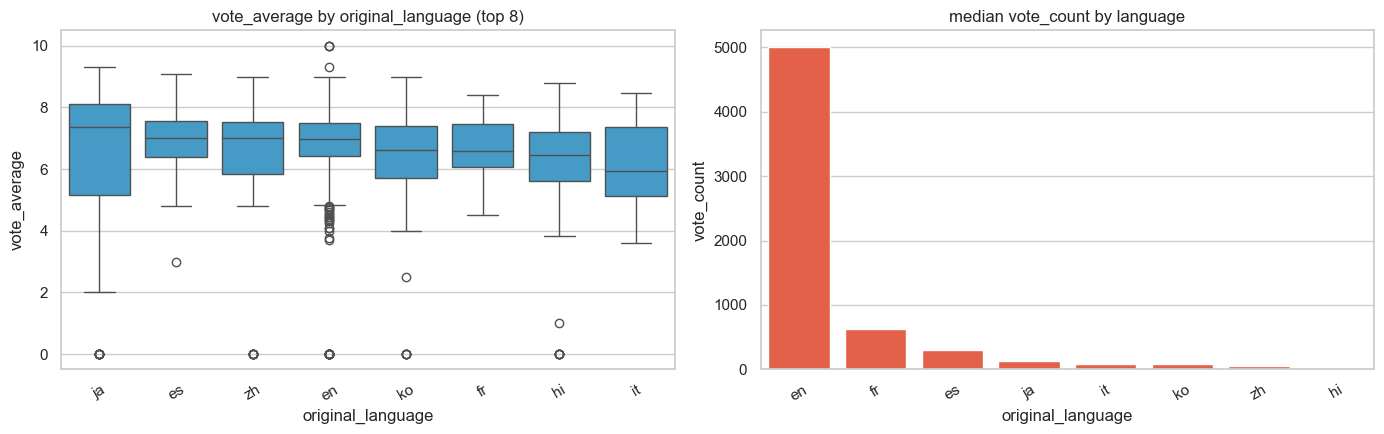

AGENT_SUMMARY language_rating:
                       n  mean_rating  median_votes
original_language                                 
en                 1470         6.86        5011.0
ja                   80         6.22         126.0
ko                   69         6.14          82.0
zh                   51         5.96          47.0
fr                   46         6.67         621.5
es                   42         6.85         295.5
hi                   37         5.50          25.0
it                   30         6.21          88.0


In [8]:
# Language × rating (top languages by volume)
top_langs = df["original_language"].value_counts().head(8).index
lang_df = df[df["original_language"].isin(top_langs)].copy()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
order = lang_df.groupby("original_language")["vote_average"].median().sort_values(ascending=False).index
sns.boxplot(data=lang_df, x="original_language", y="vote_average", order=order, ax=ax[0], color="#30a2da")
ax[0].set_title("vote_average by original_language (top 8)")
ax[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=lang_df.groupby("original_language", as_index=False)["vote_count"].median().sort_values("vote_count", ascending=False),
    x="original_language", y="vote_count", ax=ax[1], color="#fc4f30",
)
ax[1].set_title("median vote_count by language")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

summary_lang = lang_df.groupby("original_language").agg(
    n=("id", "size"),
    mean_rating=("vote_average", "mean"),
    median_votes=("vote_count", "median"),
).sort_values("n", ascending=False)
print("AGENT_SUMMARY language_rating:\n", summary_lang.round(2).to_string())


**Interpretation:** <br>
Language medians can differ by half a star or more, but sample sizes and vote volumes are uneven. A high-median language with few titles is a different story from English's thick middle. I read these as composition differences in the scrape, not as a world ranking of national cinemas.


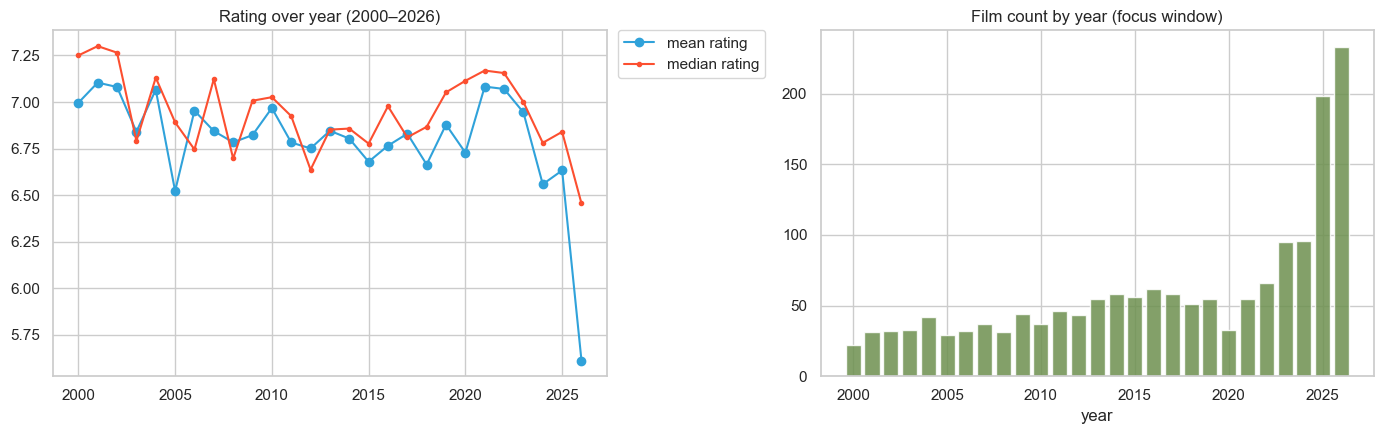

AGENT_SUMMARY year_rating_corr_spearman=-0.424
AGENT_SUMMARY language_diversity_2000=5 language_diversity_2024=16


In [9]:
# Year × rating trends (focus on years with enough films)
focus = df[df["year"].between(2000, 2026)].copy()
assert len(focus) > 500, "focus window unexpectedly thin"

yearly = focus.groupby("year").agg(
    n=("id", "size"),
    mean_rating=("vote_average", "mean"),
    median_rating=("vote_average", "median"),
    median_votes=("vote_count", "median"),
).reset_index()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(yearly["year"], yearly["mean_rating"], color="#30a2da", marker="o", label="mean rating")
ax[0].plot(yearly["year"], yearly["median_rating"], color="#fc4f30", marker=".", label="median rating")
ax[0].set_title("Rating over year (2000–2026)")
ax[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

ax[1].bar(yearly["year"], yearly["n"], color="#6d904f", alpha=0.85)
ax[1].set_title("Film count by year (focus window)")
ax[1].set_xlabel("year")
plt.tight_layout()
plt.show()

# Language diversity over years
diversity = focus.groupby("year")["original_language"].nunique().reset_index(name="n_languages")
print("AGENT_SUMMARY year_rating_corr_spearman={:.3f}".format(
    stats.spearmanr(yearly["year"], yearly["mean_rating"]).correlation
))
print("AGENT_SUMMARY language_diversity_2000={:.0f} language_diversity_2024={:.0f}".format(
    diversity.loc[diversity["year"] == 2000, "n_languages"].values[0] if (diversity["year"] == 2000).any() else np.nan,
    diversity.loc[diversity["year"] == 2024, "n_languages"].values[0] if (diversity["year"] == 2024).any() else np.nan,
))


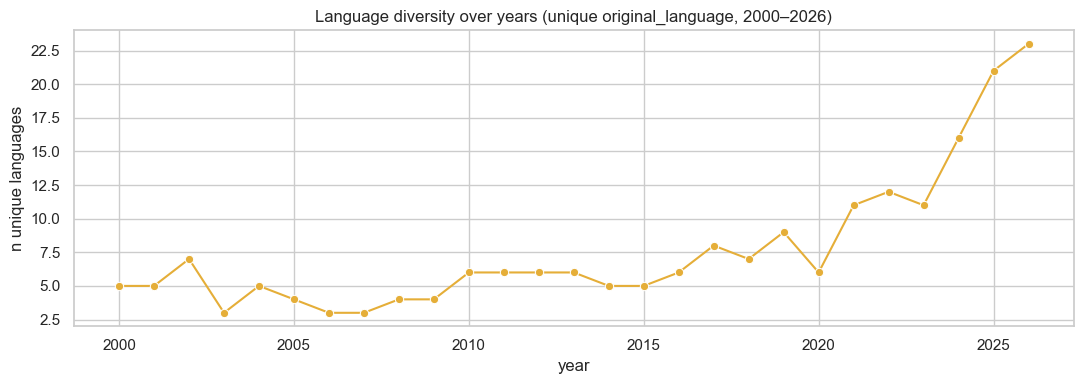

AGENT_SUMMARY diversity_table_tail:
   year  n_languages
2019.0            9
2020.0            6
2021.0           11
2022.0           12
2023.0           11
2024.0           16
2025.0           21
2026.0           23


In [10]:
f, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=diversity, x="year", y="n_languages", color="#e5ae38", marker="o", ax=ax)
ax.set_title("Language diversity over years (unique original_language, 2000–2026)")
ax.set_ylabel("n unique languages")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY diversity_table_tail:\n", diversity.tail(8).to_string(index=False))


**How to Interpret:** <br>
Year-mean ratings wiggle with composition: more franchise films, more niche festival entries, or scrape bias can move the mean without any true "quality" trend. Language diversity rising (or flatlining) tells me whether the catalog is broadening beyond English in this sample — still a sample artifact until triangulated with a fuller database.


# **6. Overview Text Features:** <a id="Text"></a>


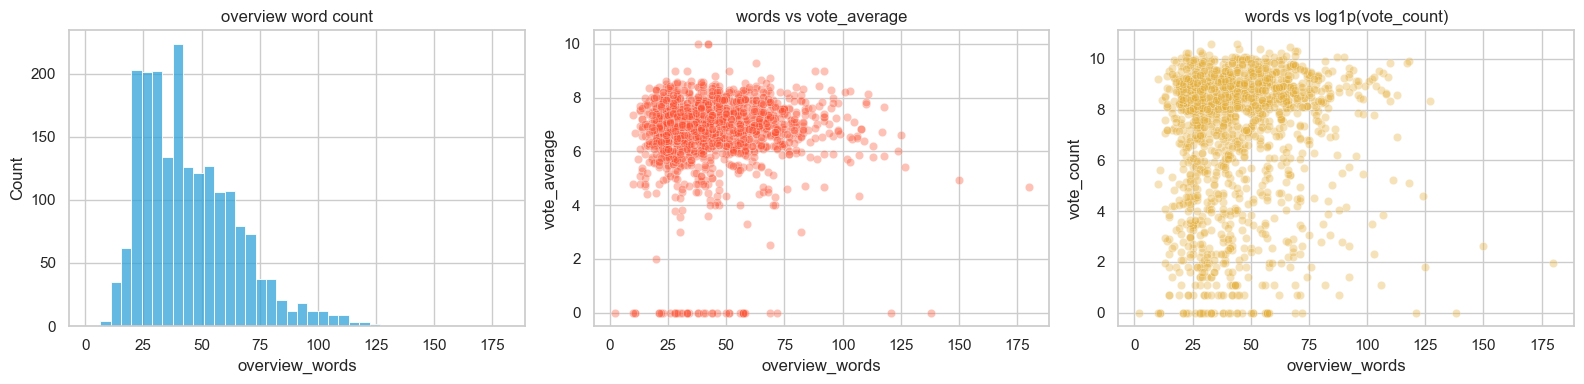

AGENT_SUMMARY overview_words: mean=44.9 median=41
AGENT_SUMMARY spearman words~rating=0.039 (p=0.086) words~votes=0.122 (p=4.5e-08)


In [11]:
# Overview length vs rating / votes
text_df = df[df["overview_words"] > 0].copy()

f, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(text_df["overview_words"], bins=40, ax=ax[0], color="#30a2da")
ax[0].set_title("overview word count")

sns.scatterplot(
    data=text_df.sample(min(1500, len(text_df)), random_state=0),
    x="overview_words", y="vote_average", alpha=0.35, ax=ax[1], color="#fc4f30",
)
ax[1].set_title("words vs vote_average")

sns.scatterplot(
    data=text_df.sample(min(1500, len(text_df)), random_state=0),
    x="overview_words", y=np.log1p(text_df.sample(min(1500, len(text_df)), random_state=0)["vote_count"]),
    alpha=0.35, ax=ax[2], color="#e5ae38",
)
ax[2].set_title("words vs log1p(vote_count)")
plt.tight_layout()
plt.show()

r_rating = stats.spearmanr(text_df["overview_words"], text_df["vote_average"])
r_votes = stats.spearmanr(text_df["overview_words"], text_df["vote_count"])
print("AGENT_SUMMARY overview_words: mean={:.1f} median={:.0f}".format(
    text_df["overview_words"].mean(), text_df["overview_words"].median()
))
print("AGENT_SUMMARY spearman words~rating={:.3f} (p={:.2g}) words~votes={:.3f} (p={:.2g})".format(
    r_rating.correlation, r_rating.pvalue, r_votes.correlation, r_votes.pvalue
))


**Interpretation:** <br>
Overview length is a weak, noisy companion to rating. If anything associates, it is usually more with *attention* (vote count) than with stars — longer blurbs may mark bigger marketing packages, not better films. Empty overviews are rare here; I dropped zero-word rows before correlating so the association is not an artifact of missing text coded as length zero.


# **7. Top and Bottom Films:** <a id="Tops"></a>


In [12]:
# Top / bottom by rating with a minimum vote threshold (avoid tiny-sample stars)
MIN_VOTES = max(50, int(df["vote_count"].quantile(0.25)))
eligible = df[df["vote_count"] >= MIN_VOTES].copy()
assert len(eligible) > 100, "vote threshold too strict"

top10 = eligible.nlargest(10, "vote_average")[["title", "year", "original_language", "vote_average", "vote_count"]]
bottom10 = eligible.nsmallest(10, "vote_average")[["title", "year", "original_language", "vote_average", "vote_count"]]
most_voted = df.nlargest(10, "vote_count")[["title", "year", "vote_average", "vote_count"]]

print(f"Eligible films with vote_count >= {MIN_VOTES}: {len(eligible)}")
print("\n=== Highest rated (vote-filtered) ===")
display(top10.reset_index(drop=True))
print("=== Lowest rated (vote-filtered) ===")
display(bottom10.reset_index(drop=True))
print("=== Most voted (no rating filter) ===")
display(most_voted.reset_index(drop=True))


Eligible films with vote_count >= 234: 1501

=== Highest rated (vote-filtered) ===


,title,year,original_language,vote_average,vote_count
0,Swapped,2026.0,en,8.976,1540
1,The Shawshank Redemption,1994.0,en,8.721,30472
2,The Godfather,1972.0,en,8.687,22981
3,Project Hail Mary,2026.0,en,8.654,4562
4,Succubus,2024.0,en,8.574,236
5,The Godfather Part II,1974.0,en,8.571,13931
6,Schindler's List,1993.0,en,8.568,17478
7,12 Angry Men,1957.0,en,8.561,10003
8,Spirited Away,2001.0,ja,8.535,18347
9,Remarkably Bright Creatures,2026.0,en,8.533,532


=== Lowest rated (vote-filtered) ===


,title,year,original_language,vote_average,vote_count
0,The Human Centipede 3 (Final Sequence),2015.0,en,3.776,852
1,War of the Worlds,2025.0,en,4.105,1002
2,Snow White,2025.0,en,4.317,1635
3,Batman & Robin,1997.0,en,4.395,5408
4,Mortal Kombat: Annihilation,1997.0,en,4.557,1345
5,Swept Away,2002.0,en,4.700,312
6,The Human Centipede 2 (Full Sequence),2011.0,en,4.764,1447
7,Scary Movie 5,2013.0,en,4.791,3031
8,Baise-moi,2000.0,fr,4.840,487
9,Zombie Strippers!,2008.0,en,4.857,427


=== Most voted (no rating filter) ===


,title,year,vote_average,vote_count
0,Interstellar,2014.0,8.476,39900
1,Inception,2010.0,8.372,39304
2,The Avengers,2012.0,8.035,38138
3,The Dark Knight,2008.0,8.531,35827
4,Avatar,2009.0,7.605,34003
5,Deadpool,2016.0,7.623,32741
6,Fight Club,1999.0,8.438,32074
7,Avengers: Infinity War,2018.0,8.236,32035
8,The Shawshank Redemption,1994.0,8.721,30472
9,Pulp Fiction,1994.0,8.483,30229


**Code Explanation:** <br>
Unfiltered "top rated" lists are polluted by titles with a handful of generous votes. I impose a minimum vote threshold (at least the 25th percentile, floored at 50) before ranking by `vote_average`, and separately list the raw attention leaders by `vote_count`.


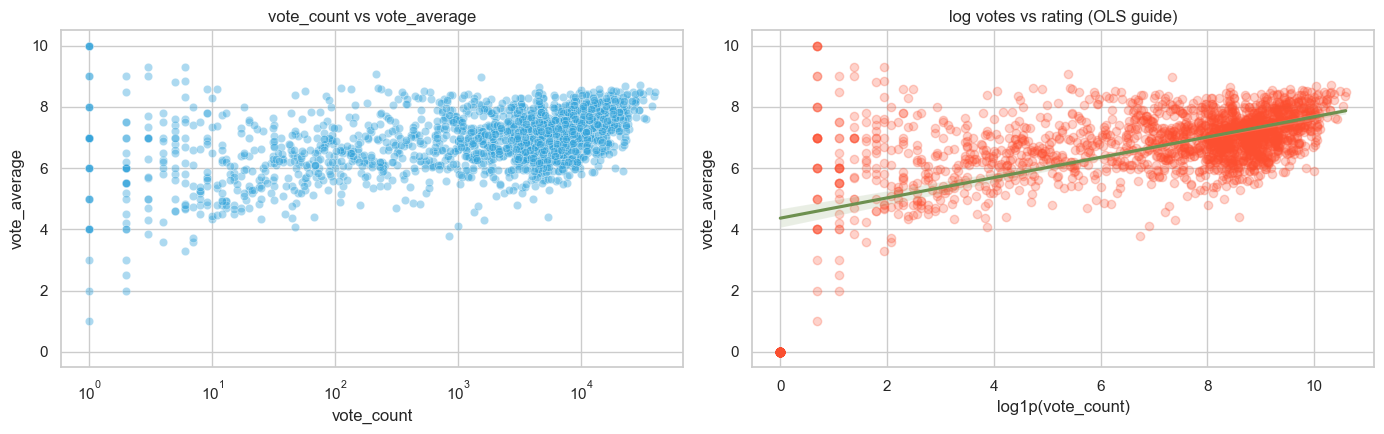

AGENT_SUMMARY spearman vote_count~vote_average=0.474 p=1.6e-112
AGENT_SUMMARY mean_rating by vote tertile:
        mean  count
vt                
low   5.805    667
mid   6.923    666
high  7.295    667


In [13]:
# Correlation: vote_count vs vote_average — popularity trap
f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sample = df.sample(min(2000, len(df)), random_state=1)
sns.scatterplot(data=sample, x="vote_count", y="vote_average", alpha=0.4, ax=ax[0], color="#30a2da")
ax[0].set_xscale("log")
ax[0].set_title("vote_count vs vote_average")

sns.regplot(
    data=sample, x=np.log1p(sample["vote_count"]), y="vote_average",
    scatter_kws={"alpha": 0.25, "color": "#fc4f30"},
    line_kws={"color": "#6d904f"}, ax=ax[1],
)
ax[1].set_xlabel("log1p(vote_count)")
ax[1].set_title("log votes vs rating (OLS guide)")
plt.tight_layout()
plt.show()

rho = stats.spearmanr(df["vote_count"], df["vote_average"])
print("AGENT_SUMMARY spearman vote_count~vote_average={:.3f} p={:.2g}".format(rho.correlation, rho.pvalue))
print("AGENT_SUMMARY mean_rating by vote tertile:\n",
      df.assign(vt=pd.qcut(df["vote_count"], 3, labels=["low", "mid", "high"]))
      .groupby("vt", observed=True)["vote_average"].agg(["mean", "count"]).round(3).to_string())


**How to Interpret:** <br>
A positive vote–rating association can mean quality draws attention — or that forgotten films leave the catalog, or that rating systems stabilize after many votes. The "popularity trap" is reading high `vote_average` on a thin vote base as proven excellence. Always pair the star with the ballot size.


# **8. What Associates with High Rating:** <a id="Association"></a>


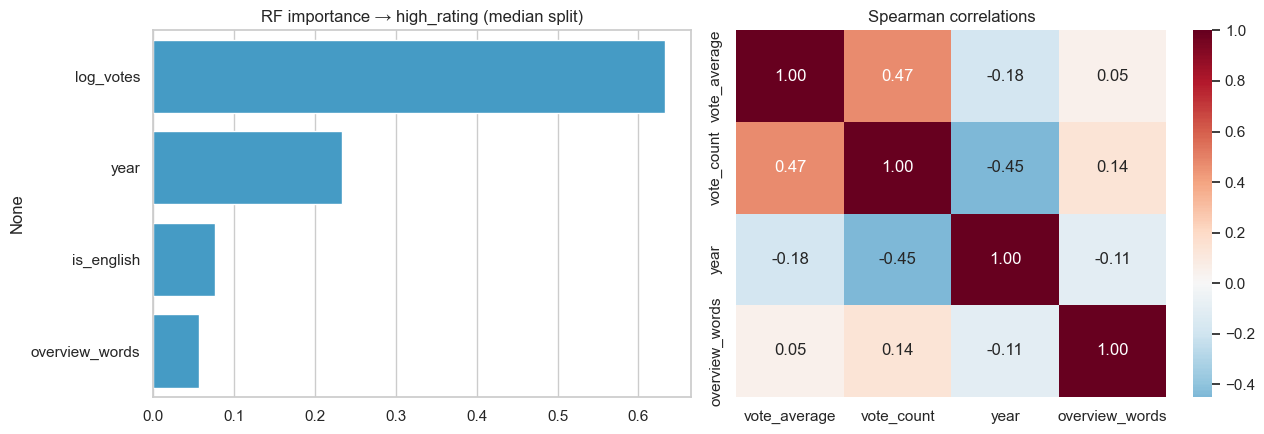

AGENT_SUMMARY rf_importances:
 log_votes         0.633
year              0.233
is_english        0.077
overview_words    0.057
AGENT_SUMMARY oob_not_used train_acc=0.749 base_rate=0.501


In [14]:
# Associational model — honest caveats, not a recommender
model_df = df.dropna(subset=["year"]).copy()
model_df["log_votes"] = np.log1p(model_df["vote_count"])
model_df["is_english"] = (model_df["original_language"] == "en").astype(int)
model_df["high_rating"] = (model_df["vote_average"] >= model_df["vote_average"].median()).astype(int)

feat_num = ["year", "log_votes", "overview_words", "is_english"]
X = model_df[feat_num]
y = model_df["high_rating"]
assert X.isna().sum().sum() == 0

rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=20,
    random_state=0, n_jobs=-1,
)
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=feat_num).sort_values(ascending=False)

# Continuous correlations for context
corr = model_df[["vote_average", "vote_count", "year", "overview_words"]].corr(method="spearman")

f, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=imp.values, y=imp.index, ax=ax[0], color="#30a2da")
ax[0].set_title("RF importance → high_rating (median split)")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title("Spearman correlations")
plt.tight_layout()
plt.show()

print("AGENT_SUMMARY rf_importances:\n", imp.round(3).to_string())
print("AGENT_SUMMARY oob_not_used train_acc={:.3f} base_rate={:.3f}".format(
    rf.score(X, y), y.mean()
))


**How to Interpret:** <br>
These importances are fit on the *full* table for exploration — a nonlinear companion to the Spearman board, not a validated predictor. `log_votes` will often dominate because attention and rating co-move in scraped catalogs. Year and English flags can proxy era and market, not intrinsic quality. I would not ship this as a ranking model; I would use it to decide which bivariate plots deserved more ink.


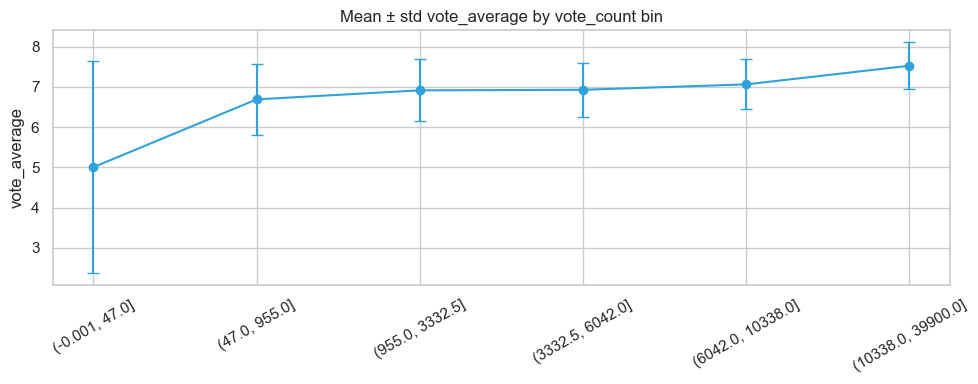

AGENT_SUMMARY rating_stability:
                      mean    std  count
vote_bin                               
(-0.001, 47.0]      5.007  2.632    334
(47.0, 955.0]       6.691  0.885    332
(955.0, 3332.5]     6.915  0.767    332
(3332.5, 6042.0]    6.929  0.670    333
(6042.0, 10338.0]   7.063  0.622    332
(10338.0, 39900.0]  7.527  0.590    333


In [15]:
# Rating stability: variance of vote_average within vote-count bins
model_df["vote_bin"] = pd.qcut(model_df["vote_count"], 6, duplicates="drop")
stab = model_df.groupby("vote_bin", observed=True)["vote_average"].agg(["mean", "std", "count"])
f, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(range(len(stab)), stab["mean"], yerr=stab["std"], fmt="o-", color="#30a2da", capsize=4)
ax.set_xticks(range(len(stab)))
ax.set_xticklabels([str(i) for i in stab.index], rotation=30)
ax.set_title("Mean ± std vote_average by vote_count bin")
ax.set_ylabel("vote_average")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY rating_stability:\n", stab.round(3).to_string())


**Interpretation:** <br>
If rating variance shrinks as vote counts grow, the catalog is showing the classic stabilization pattern: thin-vote titles wander; thick-vote titles settle. That is another face of the popularity trap — the stars that look "sure" are the ones with enough ballots to stop wiggling.


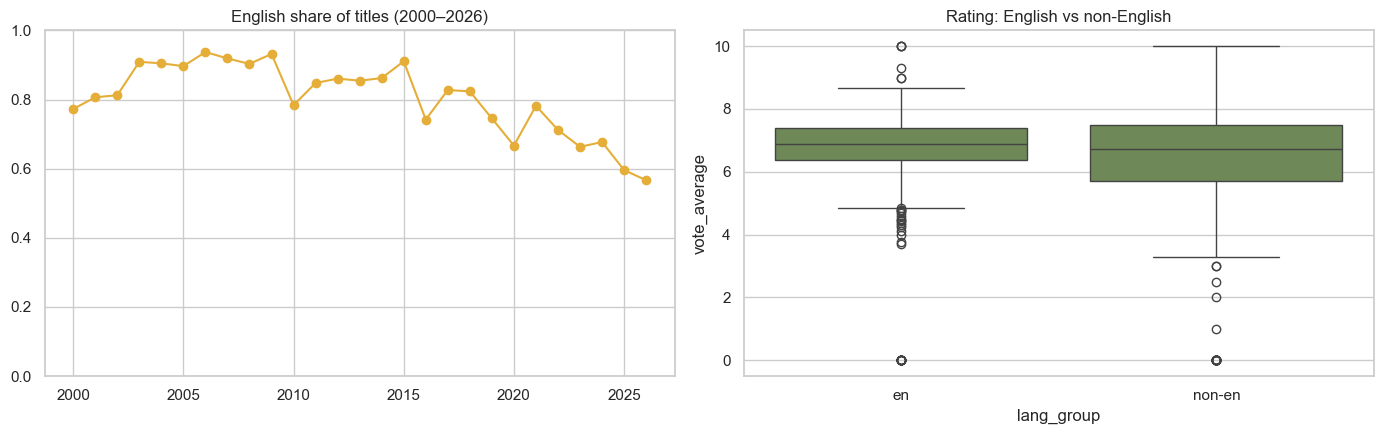

AGENT_SUMMARY eng_share_2000=0.77 eng_share_2024=0.68


In [16]:
# English vs non-English over years in the focus window
eng = focus.assign(is_en=focus["original_language"].eq("en"))
eng_year = eng.groupby("year").agg(n=("id", "size"), eng_share=("is_en", "mean"), mean_rating=("vote_average", "mean"))
f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(eng_year.index, eng_year["eng_share"], color="#e5ae38", marker="o")
ax[0].set_title("English share of titles (2000–2026)")
ax[0].set_ylim(0, 1)
sns.boxplot(data=focus.assign(lang_group=np.where(focus["original_language"].eq("en"), "en", "non-en")),
            x="lang_group", y="vote_average", ax=ax[1], color="#6d904f")
ax[1].set_title("Rating: English vs non-English")
plt.tight_layout()
plt.show()
print("AGENT_SUMMARY eng_share_2000={:.2f} eng_share_2024={:.2f}".format(
    eng_year.loc[2000, "eng_share"] if 2000 in eng_year.index else np.nan,
    eng_year.loc[2024, "eng_share"] if 2024 in eng_year.index else np.nan,
))


**Code Explanation:** <br>
English share over time asks whether the scrape internationalizes. The boxplot compares rating distributions without pretending equal sample sizes — non-English is a heterogeneous bag, useful as a coarse contrast only.


In [17]:
# Same-title / original_title quirks
print("AGENT_SUMMARY title==original_title share={:.1%}".format((df["title"] == df["original_title"]).mean()))
print("AGENT_SUMMARY duplicate titles (value_counts>1):", int((df["title"].value_counts() > 1).sum()))
dup_titles = df["title"].value_counts()
dup_titles = dup_titles[dup_titles > 1].head(8)
print(dup_titles.to_string() if len(dup_titles) else "no duplicate titles in head")


AGENT_SUMMARY title==original_title share=78.0%
AGENT_SUMMARY duplicate titles (value_counts>1): 38
title
Mortal Kombat              2
Scary Movie                2
Masters of the Universe    2
War of the Worlds          2
Superman                   2
Anaconda                   2
The Lion King              2
Dune                       2


**Interpretation:** <br>
When `title` equals `original_title` for most rows, localization is thin in this scrape. Duplicate title strings (if any) are remakes, collisions, or data entry echoes — worth a glance before treating title as a unique key (id remains the safer key).


# **9. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A compact TMDB-style movie scrape (~2,000 rows) with ratings, vote volume, language, release date, and overview text. A second file looks larger but collapses to ~20 unique ids after dedupe — a hard data-quality stop sign.

**What stands out:** <br>
1. **Attention is unequal.** Vote counts follow a heavy-tailed, Pareto-like pattern; a thin head of titles owns a thick share of ballots.
2. **Stars need ballots.** Rating without vote count is fragile; the popularity trap is real in this catalog.
3. **The 2000–2026 window is a lens, not the whole support.** Older tails remain; year trends mix true composition shifts with scrape density.
4. **Language matters for composition.** English dominates volume; rating differences by language are associational and sample-size sensitive.
5. **Overview length is a weak signal.** Word count barely tracks rating; any link is likelier to attention than quality.
6. **RF importances echo the bivariate story.** Vote volume associates with "high rating" splits more than text length — with all the circularity that implies.

**Open follow-ups:** <br>
- How would genre or budget (absent here) reshape the vote–rating relationship?
- Is language diversity rising because of true internationalization or because recent scrapes are denser?
- Would a vote-weighted rating estimator change the top/bottom film lists materially?
- Can overview *content* (sentiment, named entities) beat overview *length*?
